In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from features import build_hunting_features, build_rut_features
from grid import create_grid, spatial_join_points_to_grid
from roads import (
    build_road_features,
    load_roads_for_study_area,
    build_linear_features,
    load_linear_layer_for_study_area,
    build_speedlimit_features,
)
from weather import build_cell_month_temperature, build_cell_month_precipitation


In [2]:
def load_collision_data(path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, sep=";", encoding="latin1", low_memory=False)

    df = df.rename(columns={
        "Datum":       "datetime",
        "Viltslag":    "species",
        "Län":         "lan",
        "Kommun":      "kommun",
        "Lat WGS84":   "lat",
        "Long WGS84":  "lon",
    })

    # Parse coordinates (Swedish decimal-comma → dot)
    for col in ("lat", "lon"):
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce",
        )

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=False)
    df = df.dropna(subset=["datetime", "lat", "lon"])

    # Keep only plausible Sweden WGS84 bounding box
    df = df[df["lat"].between(55, 70) & df["lon"].between(10, 25)]

    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:3006")


def load_collision_data_multi_year(folder_path: str) -> gpd.GeoDataFrame:
    folder = Path(folder_path)
    files  = sorted(folder.glob("*.csv"))
    if not files:
        raise ValueError("No CSV files found in folder")
    print(f"Found {len(files)} files")
    gdfs = [load_collision_data(str(f)) for f in files]
    gdf  = pd.concat(gdfs, ignore_index=True)
    print("Combined shape:", gdf.shape)
    return gdf


DATA_DIR = "C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data"

# Single load — everything downstream uses `gdf`
gdf = load_collision_data_multi_year(f"{DATA_DIR}/Collisions")
gdf = gdf[gdf["datetime"].dt.year <= 2025]



Found 12 files
Combined shape: (732678, 16)


In [3]:
def build_cell_month_table_full(gdf_points, cell_size=10000):
    grid   = create_grid(gdf_points, cell_size=cell_size)
    joined = spatial_join_points_to_grid(gdf_points, grid)
    joined = joined.dropna(subset=["cell_id"])
    joined["cell_id"]      = joined["cell_id"].astype(int)
    joined["period_start"] = joined["datetime"].dt.to_period("M").dt.to_timestamp()

    observed = (
        joined.groupby(["cell_id", "period_start"])
        .size()
        .reset_index(name="collision_count")
    )


    # Full month range
    periods    = gdf_points["datetime"].dt.to_period("M")
    min_month  = periods.min().to_timestamp()
    max_month  = periods.max().to_timestamp()
    all_months = pd.date_range(start=min_month, end=max_month, freq="MS")


    full_index = pd.MultiIndex.from_product(
        [grid["cell_id"].astype(int).unique(), all_months],
        names=["cell_id", "period_start"],
    )
    cell_month = (
        full_index.to_frame(index=False)
        .merge(observed, on=["cell_id", "period_start"], how="left")
    )
    cell_month["collision_count"] = cell_month["collision_count"].fillna(0).astype(int)

    # High-risk label: top 25 % of non-zero months
    nonzero = cell_month.loc[cell_month["collision_count"] > 0, "collision_count"]
    if nonzero.empty:
        raise ValueError("No non-zero collision counts; cannot define risk threshold.")
    threshold = nonzero.quantile(0.75)
    cell_month["risk"] = (cell_month["collision_count"] >= threshold).astype(int)

    print("High-risk threshold:", threshold)
    print(cell_month["risk"].value_counts())
    return grid, joined, cell_month


grid, joined, cell_month = build_cell_month_table_full(gdf, cell_size=10000)


High-risk threshold: 4.0
risk
0    1305119
1      70189
Name: count, dtype: int64


In [4]:
SPECIES_MAP = {
    "älg":      "moose",
    "rådjur":   "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

daylight_df = gdf[gdf["datetime"].dt.year <= 2025].copy()
daylight_df["species"] = (
    daylight_df["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
)
daylight_df["hour"]  = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month


def vectorised_light_condition(df: pd.DataFrame) -> pd.Series:
    h, m = df["hour"], df["month"]
    winter = m.isin([12, 1, 2])
    summer = m.isin([6, 7, 8])
    spring_autumn = ~(winter | summer)

    conditions = [
        winter & h.between(9, 14),
        winter & h.between(7, 8),
        winter & h.between(15, 16),
        summer & h.between(5, 20),
        summer & h.between(3, 4),
        summer & h.between(21, 22),
        spring_autumn & h.between(7, 17),
        spring_autumn & h.between(5, 6),
        spring_autumn & h.between(18, 19),
    ]
    choices = ["day", "dawn", "dusk", "day", "dawn", "dusk", "day", "dawn", "dusk"]
    return np.select(conditions, choices, default="night")


daylight_df["light_condition"] = vectorised_light_condition(daylight_df)

print(daylight_df[["datetime", "hour", "species", "light_condition"]].head())


             datetime  hour      species light_condition
0 2015-01-01 00:21:00     0  fallow_deer           night
1 2015-01-01 01:30:00     1        moose           night
2 2015-01-01 01:36:00     1    wild_boar           night
3 2015-01-01 01:50:00     1    wild_boar           night
4 2015-01-01 01:50:00     1     roe_deer           night


In [5]:
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)
light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()
print(light_counts)

species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)
species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)
print(species_light.sort_values(["species", "collision_count"], ascending=[True, False]))

  light_condition  collision_count     share
0           night           302400  0.424414
1             day           226965  0.318542
2            dusk            98855  0.138742
3            dawn            84292  0.118303
        species light_condition  collision_count  species_total  \
3         björn           night               93            199   
1         björn             day               74            199   
2         björn            dusk               18            199   
0         björn            dawn               14            199   
7   fallow_deer           night            20313          52229   
5   fallow_deer             day            18226          52229   
6   fallow_deer            dusk             8243          52229   
4   fallow_deer            dawn             5447          52229   
8          järv             day               18             27   
10         järv           night                8             27   
9          järv            dusk       

In [6]:
SEASON_MAP = {
    12: "winter", 1: "winter",  2: "winter",
    3:  "spring", 4: "spring",  5: "spring",
    6:  "summer", 7: "summer",  8: "summer",
    9:  "autumn", 10: "autumn", 11: "autumn",
}
daylight_df["season"] = daylight_df["month"].map(SEASON_MAP)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
print(season_light)


    season light_condition  collision_count
0   autumn            dawn            29213
1   autumn             day            89790
2   autumn            dusk            37911
3   autumn           night            75466
4   spring            dawn            19916
5   spring             day            38742
6   spring            dusk            13830
7   spring           night            68521
8   summer            dawn            10269
9   summer             day            77267
10  summer            dusk            25835
11  summer           night            35720
12  winter            dawn            24894
13  winter             day            21166
14  winter            dusk            21279
15  winter           night           122693


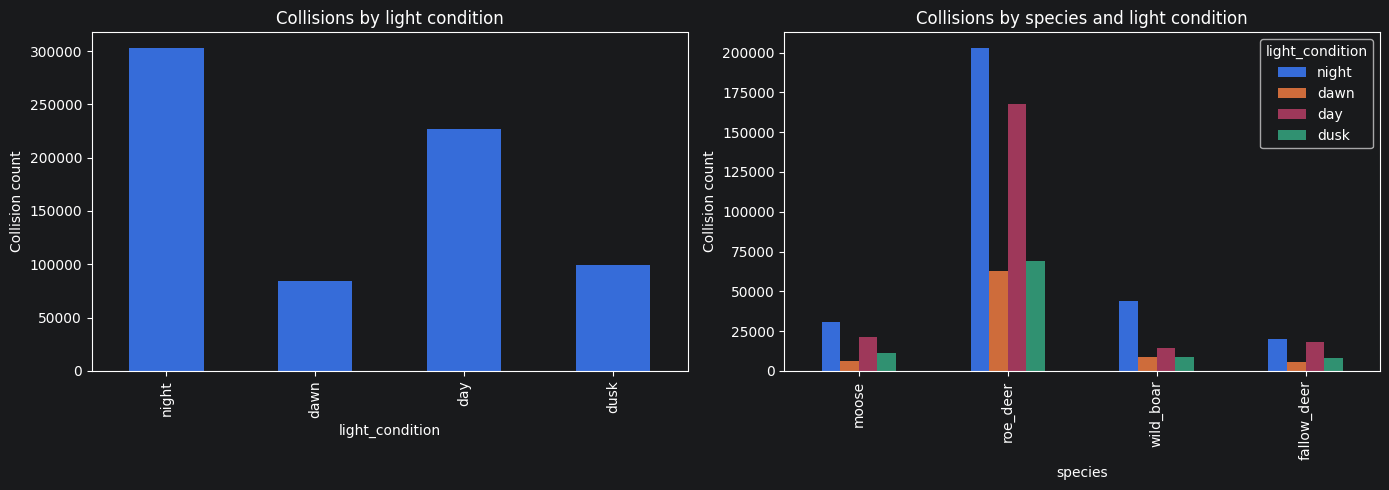

In [7]:
light_order   = ["night", "dawn", "day", "dusk"]
species_order = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daylight_df["light_condition"].value_counts().reindex(light_order).plot(
    kind="bar", ax=axes[0]
)
axes[0].set(ylabel="Collision count", title="Collisions by light condition")

(
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(species_order)
    .reindex(columns=light_order)
    .plot(kind="bar", ax=axes[1])
)
axes[1].set(ylabel="Collision count", title="Collisions by species and light condition")

plt.tight_layout()
plt.show()

In [8]:
def build_lagged_light(joined: gpd.GeoDataFrame) -> pd.DataFrame:
    df = joined[["cell_id", "datetime"]].copy()
    df["cell_id"]      = df["cell_id"].astype(int)
    df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
    df["hour"]         = df["datetime"].dt.hour

    # Simplified (time-of-day only) light classification for cell-month features
    conditions = [
        df["hour"].between(5, 7),
        df["hour"].between(8, 16),
        df["hour"].between(17, 20),
    ]
    df["light_condition"] = np.select(conditions, ["dawn", "day", "dusk"], default="night")

    light_counts = (
        df.groupby(["cell_id", "period_start", "light_condition"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    light_cols = [c for c in light_counts.columns if c not in ["cell_id", "period_start"]]
    row_sums   = light_counts[light_cols].sum(axis=1)
    light_counts[light_cols] = light_counts[light_cols].div(row_sums.where(row_sums > 0, 1), axis=0)

    light_counts = light_counts.sort_values(["cell_id", "period_start"])
    for col in light_cols:
        light_counts[f"{col}_lag1"] = light_counts.groupby("cell_id")[col].shift(1)

    lag_cols = [f"{c}_lag1" for c in light_cols]
    return light_counts[["cell_id", "period_start"] + lag_cols].fillna(0)


lagged_light = build_lagged_light(joined)


In [9]:
def build_lagged_species(joined: gpd.GeoDataFrame) -> pd.DataFrame:
    relevant = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

    df = joined[["cell_id", "datetime", "species"]].copy()
    df["cell_id"]      = df["cell_id"].astype(int)
    df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
    df["species"]      = (
        df["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
    )
    df = df[df["species"].isin(relevant)]

    species_counts = (
        df.groupby(["cell_id", "period_start", "species"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .sort_values(["cell_id", "period_start"])
    )

    species_cols = [c for c in species_counts.columns if c not in ["cell_id", "period_start"]]
    for col in species_cols:
        species_counts[f"{col}_lag1"] = species_counts.groupby("cell_id")[col].shift(1)

    lag_cols = [f"{c}_lag1" for c in species_cols]
    return species_counts[["cell_id", "period_start"] + lag_cols].fillna(0)


lagged_species = build_lagged_species(joined)


In [10]:
roads = load_roads_for_study_area(
    path=f"{DATA_DIR}/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)
road_features = build_road_features(
    grid=grid,
    roads=roads,
    keep_only_classes=["bilnät"],
)

model_df = (
    cell_month
    .merge(road_features.drop(columns="geometry"), on="cell_id", how="left")
    .query("road_length_m > 0")
)


railways = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)
rail_features = build_linear_features(grid=grid, lines=railways, prefix="rail")

model_df = model_df.merge(
    rail_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left",
)
for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["rail_near_10km"] = (model_df["nearest_rail_distance_m"] < 10_000).astype(int)


fences = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Barrairanalys/Barriaranalys.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
    layer="barriarer_kvarvarande_vag",
)
fence_features = build_linear_features(grid=grid, lines=fences, prefix="fence")

model_df = model_df.merge(
    fence_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left",
)
for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
    model_df[col] = model_df[col].fillna(0)
model_df["fence_near_10km"] = (model_df["nearest_fence_distance_m"] < 10_000).astype(int)


speedlimit = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Speedlimit/ISA.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)

speedlimit_features = build_speedlimit_features(
    grid=grid,
    speedlimit_gdf=speedlimit,
    speed_col="HTHAST",
)

model_df = model_df.merge(
    speedlimit_features.drop(columns="geometry"),
    on="cell_id",
    how="left",
)

for col in [
    "speedlimit_mean_weighted",
    "speedlimit_max",
    "speedlimit_min",
    "speedlimit_90plus_share",
    "speedlimit_segment_length_m",
]:
    model_df[col] = model_df[col].fillna(0)

print(model_df[[
    "speedlimit_mean_weighted",
    "speedlimit_max",
    "speedlimit_min",
    "speedlimit_90plus_share",
    "speedlimit_segment_length_m"
]].describe())

       speedlimit_mean_weighted  speedlimit_max  speedlimit_min  \
count             601920.000000   601920.000000   601920.000000   
mean                  67.672920       81.989035       47.926535   
std                   11.394075       18.018399       21.041541   
min                    0.000000        0.000000        0.000000   
25%                   68.956669       70.000000       30.000000   
50%                   70.000000       80.000000       50.000000   
75%                   70.666799       90.000000       70.000000   
max                   97.274989      120.000000       90.000000   

       speedlimit_90plus_share  speedlimit_segment_length_m  
count            601920.000000                 6.019200e+05  
mean                  0.036716                 1.447155e+05  
std                   0.094595                 1.056907e+05  
min                   0.000000                 0.000000e+00  
25%                   0.000000                 7.105423e+04  
50%                   0.

In [11]:
relevant_cell_ids = model_df["cell_id"].unique()
grid_small = grid[grid["cell_id"].isin(relevant_cell_ids)]
print("Original grid:", grid.shape, "→ Filtered:", grid_small.shape)

temperature_features = build_cell_month_temperature(grid=grid_small)
model_df = model_df.merge(
    temperature_features[["cell_id", "period_start", "temp_mean", "temp_min", "temp_max"]],
    on=["cell_id", "period_start"],
    how="left",
)

precip_features = build_cell_month_precipitation(grid=grid_small)
model_df = model_df.merge(
    precip_features[["cell_id", "period_start", "precip_total"]],
    on=["cell_id", "period_start"],
    how="left",
)

model_df = model_df.dropna(
    subset=["temp_mean", "temp_min", "temp_max", "precip_total"]
).copy()

print(model_df[["precip_total"]].describe())


Original grid: (10419, 2) → Filtered: (4471, 2)
        precip_total
count  147828.000000
mean       44.911614
std        27.589264
min         1.400000
25%        24.100000
50%        41.000000
75%        60.400000
max       198.300000


In [12]:
model_df = model_df.merge(lagged_species, on=["cell_id", "period_start"], how="left")
lag_cols = ["moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1"]
for col in lag_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(lagged_light, on=["cell_id", "period_start"], how="left")
light_lag_cols = [c for c in lagged_light.columns if c not in ["cell_id", "period_start"]]
for col in light_lag_cols:
    model_df[col] = model_df[col].fillna(0)

In [13]:
model_df["month"]             = model_df["period_start"].dt.month
model_df["month_sin"]         = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"]         = np.cos(2 * np.pi * model_df["month"] / 12)
model_df = build_hunting_features(model_df)
model_df = build_rut_features(model_df)

FEATURES = [
    "road_density", "nearest_road_distance_m",
    "rail_density", "rail_near_10km",
    "fence_density", "fence_near_10km",
    "temp_mean", "temp_min", "temp_max",
    "precip_total",
    "moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1",
    "night_lag1", "dawn_lag1", "day_lag1", "dusk_lag1",
    "month_sin", "month_cos",
    "moose_hunting_frac", "wild_boar_hunting_frac", "roe_deer_hunting_frac", "fallow_deer_hunting_frac",
    "speedlimit_mean_weighted", "speedlimit_max", "speedlimit_90plus_share",
    "moose_rut_frac", "roe_deer_rut_frac","wild_boar_rut_frac","fallow_deer_rut_frac",
]

model_df_clean = model_df.dropna(subset=FEATURES).copy()
print("After dropna:", model_df_clean.shape)
print(model_df_clean["period_start"].value_counts().sort_index())

After dropna: (147828, 45)
period_start
2015-01-01    1119
2015-02-01    1119
2015-03-01    1119
2015-04-01    1119
2015-05-01    1119
              ... 
2025-08-01    1119
2025-09-01    1119
2025-10-01    1119
2025-11-01    1119
2025-12-01    1119
Name: count, Length: 132, dtype: int64


In [14]:
def make_expanding_time_splits(months, min_train_months=12, test_horizon=1):
    months = list(months)
    return [
        (months[:i], months[i:i + test_horizon])
        for i in range(min_train_months, len(months) - test_horizon + 1)
    ]


months = sorted(model_df_clean["period_start"].unique())
splits = make_expanding_time_splits(months, min_train_months=12, test_horizon=1)
print("Number of folds:", len(splits))

Number of folds: 120


In [15]:
def evaluate_time_splits(model_df, features, target, splits):
    results              = []
    oof_probs_rf         = []    # out-of-fold RF probabilities (all folds)
    oof_labels           = []    # matching true labels
    fold_importances     = []    # per-fold feature importances

    for fold_idx, (train_months, test_months) in enumerate(splits, start=1):
        train = model_df[model_df["period_start"].isin(train_months)].copy()
        test  = model_df[model_df["period_start"].isin(test_months)].copy()

        X_train, y_train = train[features], train[target]
        X_test,  y_test  = test[features],  test[target]

        if len(test) == 0 or y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        # ── Logistic Regression ──
        logreg = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
        ])
        logreg.fit(X_train, y_train)
        y_pred_lr = logreg.predict(X_test)
        y_prob_lr = logreg.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx, "model": "logreg",
            "auc":       roc_auc_score(y_test, y_prob_lr),
            "precision": precision_score(y_test, y_pred_lr, zero_division=0),
            "recall":    recall_score(y_test, y_pred_lr, zero_division=0),
            "f1":        f1_score(y_test, y_pred_lr, zero_division=0),
            "accuracy":  accuracy_score(y_test, y_pred_lr),
        })

        # ── Random Forest ──
        rf = RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        y_prob_rf = rf.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx, "model": "rf",
            "auc":       roc_auc_score(y_test, y_prob_rf),
            "precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "recall":    recall_score(y_test, y_pred_rf, zero_division=0),
            "f1":        f1_score(y_test, y_pred_rf, zero_division=0),
            "accuracy":  accuracy_score(y_test, y_pred_rf),
        })

        # Accumulate for post-loop analysis
        oof_probs_rf.extend(y_prob_rf.tolist())
        oof_labels.extend(y_test.tolist())
        fold_importances.append(
            pd.Series(rf.feature_importances_, index=features)
        )

    results_df = pd.DataFrame(results)

    mean_importance = pd.concat(fold_importances, axis=1).mean(axis=1).sort_values(ascending=False)

    return results_df, np.array(oof_probs_rf), np.array(oof_labels), mean_importance


results_df, oof_probs, oof_labels, mean_importance = evaluate_time_splits(
    model_df=model_df_clean,
    features=FEATURES,
    target="risk",
    splits=splits,
)

print(results_df.head())

summary = (
    results_df.groupby("model")[["auc", "precision", "recall", "f1", "accuracy"]]
    .agg(["mean", "std"])
    .round(3)
)
print(summary)
print("\nMean feature importances across all folds:")
print(mean_importance)

joined["species"].value_counts(normalize=True)


   fold   model       auc  precision    recall        f1  accuracy
0     1  logreg  0.945660   0.341398  1.000000  0.509018  0.781055
1     1      rf  0.947827   0.722222  0.307087  0.430939  0.907954
2     2  logreg  0.953956   0.288288  0.969697  0.444444  0.857015
3     2      rf  0.948732   0.695652  0.242424  0.359551  0.949062
4     3  logreg  0.931885   0.218978  0.666667  0.329670  0.890974
          auc        precision        recall           f1        accuracy  \
         mean    std      mean    std   mean    std  mean    std     mean   
model                                                                       
logreg  0.955  0.007     0.433  0.078  0.943  0.048  0.59  0.077    0.850   
rf      0.958  0.010     0.778  0.077  0.452  0.139  0.56  0.125    0.923   

               
          std  
model          
logreg  0.027  
rf      0.016  

Mean feature importances across all folds:
roe_deer_lag1               0.178811
road_density                0.178667
night_lag1    

species
Rådjur         0.704946
Vildsvin       0.106177
Älg            0.097966
Dovhjort       0.073303
Övriga djur    0.006704
Kronhjort      0.006598
Utter          0.001777
Örn            0.001128
Lo             0.000660
Varg           0.000305
Björn          0.000279
Mufflonfår     0.000119
Järv           0.000038
Name: proportion, dtype: float64

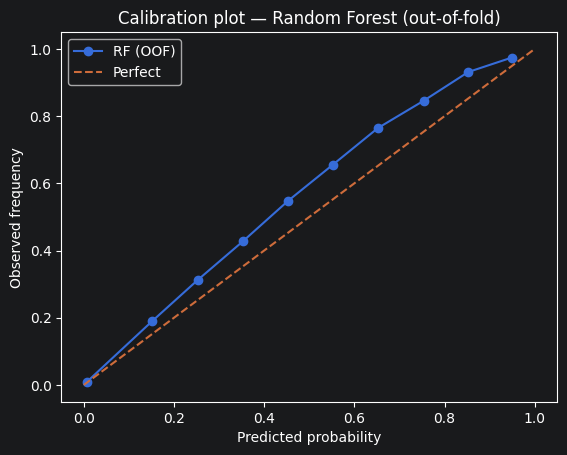

In [16]:
prob_true, prob_pred = calibration_curve(oof_labels, oof_probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="RF (OOF)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration plot — Random Forest (out-of-fold)")
plt.legend()
plt.show()

In [17]:
X_all = model_df_clean[FEATURES]
y_all = model_df_clean["risk"]

rf_final = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_final.fit(X_all, y_all)

rf_calibrated = CalibratedClassifierCV(rf_final, method="isotonic", cv=3)
rf_calibrated.fit(X_all, y_all)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

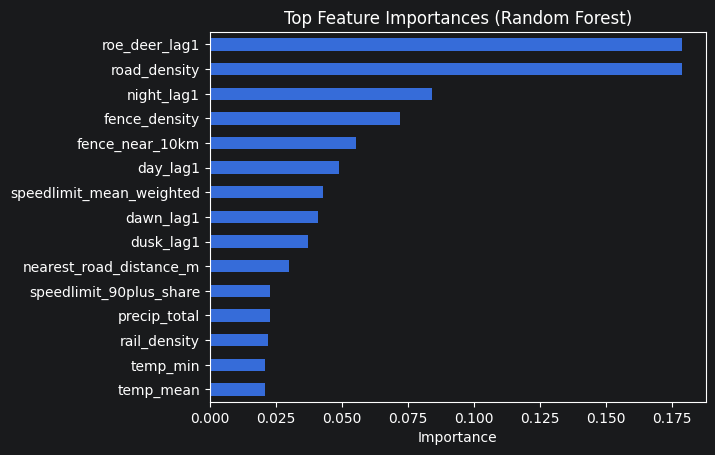

In [18]:
top_features = mean_importance.head(15)

top_features.sort_values().plot(kind="barh")
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [19]:
model_df_clean[["speedlimit_mean_weighted", "speedlimit_max", "speedlimit_90plus_share"]].corr()


,speedlimit_mean_weighted,speedlimit_max,speedlimit_90plus_share
speedlimit_mean_weighted,1.000000,0.621379,0.211745
speedlimit_max,0.621379,1.000000,0.339538
speedlimit_90plus_share,0.211745,0.339538,1.000000


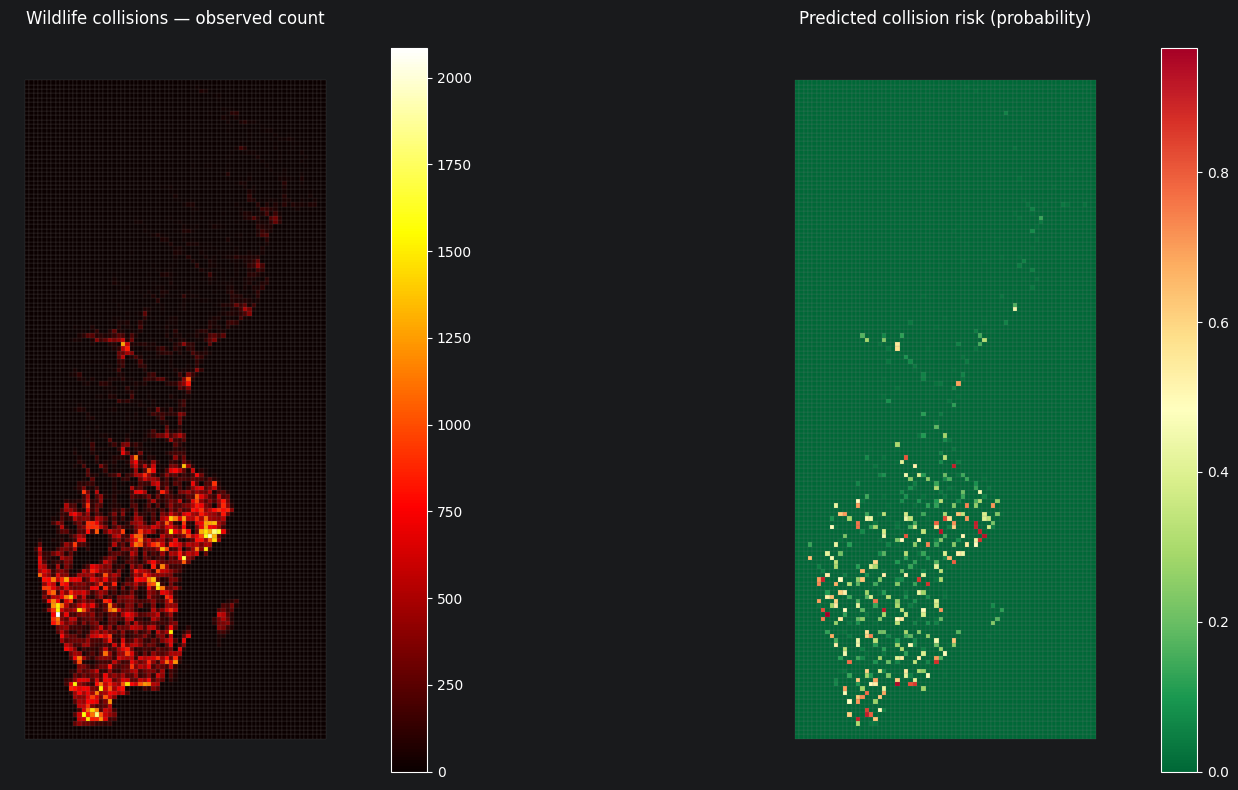

In [20]:
model_df_clean = model_df_clean.copy()
model_df_clean["risk_prob"] = rf_final.predict_proba(model_df_clean[FEATURES])[:, 1]

cell_risk = model_df_clean.groupby("cell_id")["risk_prob"].mean().reset_index()
grid_risk = grid.merge(cell_risk, on="cell_id", how="left")
grid_risk["risk_prob"] = grid_risk["risk_prob"].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap — raw collision counts
cell_totals  = joined.groupby("cell_id").size().reset_index(name="collision_count")
grid_heatmap = grid.merge(cell_totals, on="cell_id", how="left")
grid_heatmap["collision_count"] = grid_heatmap["collision_count"].fillna(0)

grid_heatmap.plot(
    column="collision_count", cmap="hot",
    linewidth=0.1, edgecolor="grey", legend=True, ax=axes[0],
)
axes[0].set_title("Wildlife collisions — observed count")
axes[0].set_axis_off()

# Risk probability map
grid_risk.plot(
    column="risk_prob", cmap="RdYlGn_r",
    linewidth=0.1, edgecolor="grey", legend=True, ax=axes[1],
)
axes[1].set_title("Predicted collision risk (probability)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

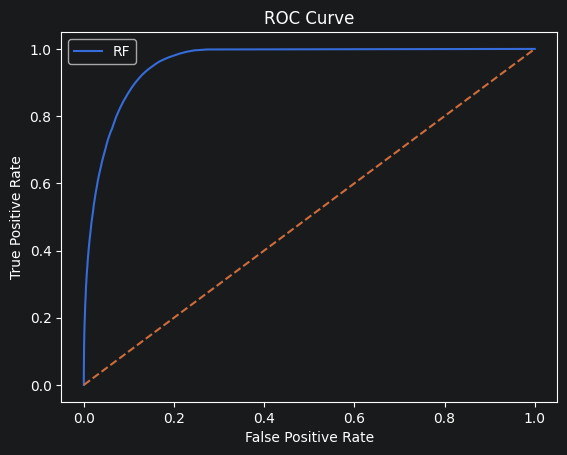

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(oof_labels, oof_probs)

plt.figure()
plt.plot(fpr, tpr, label="RF")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

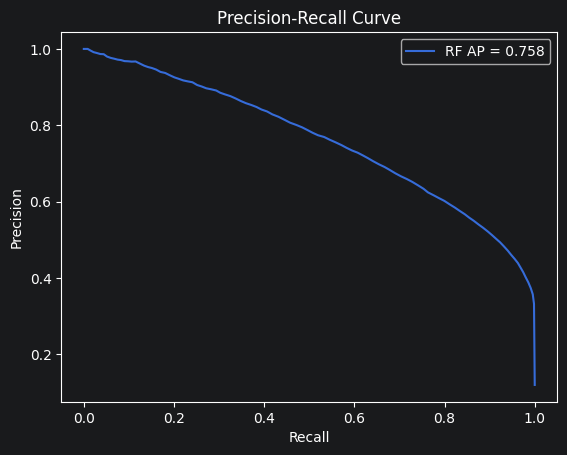

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(oof_labels, oof_probs)
ap = average_precision_score(oof_labels, oof_probs)

plt.figure()
plt.plot(recall, precision, label=f"RF AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

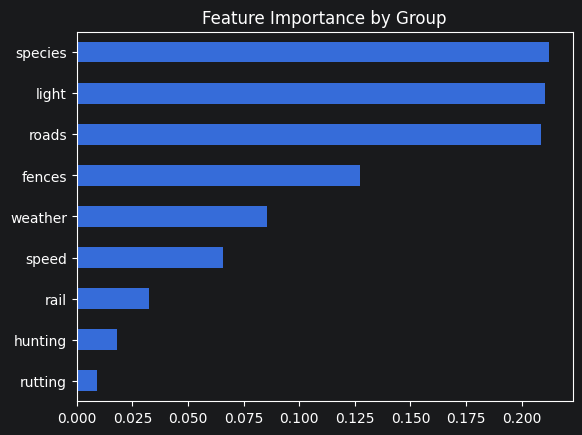

In [23]:
groups = {
    "roads": ["road_density", "nearest_road_distance_m"],
    "fences": ["fence_density", "fence_near_10km"],
    "weather": ["temp_mean", "temp_min", "temp_max", "precip_total"],
    "species": ["roe_deer_lag1", "moose_lag1", "wild_boar_lag1", "fallow_deer_lag1"],
    "light": ["night_lag1", "day_lag1", "dawn_lag1", "dusk_lag1"],
    "hunting": ["moose_hunting_frac","wild_boar_hunting_frac","roe_deer_hunting_frac","fallow_deer_hunting_frac",],
    "rutting": ["moose_rut_frac","roe_deer_rut_frac","wild_boar_rut_frac","fallow_deer_rut_frac",],
    "speed": ["speedlimit_mean_weighted","speedlimit_90plus_share",],
    "rail": ["rail_density","rail_near_10km",],
}

group_importance = {
    k: mean_importance[v].sum()
    for k, v in groups.items()
}

pd.Series(group_importance).sort_values().plot(kind="barh")
plt.title("Feature Importance by Group")
plt.show()

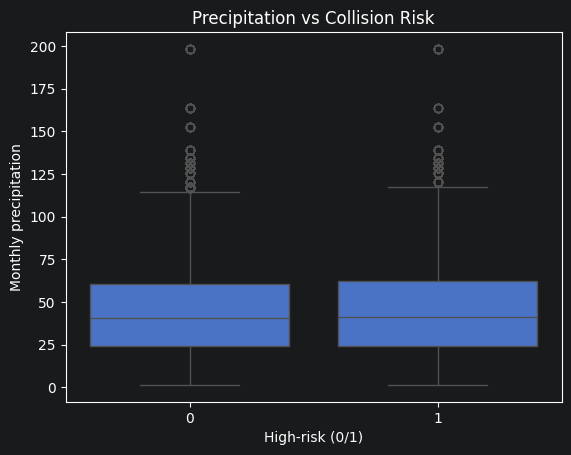

In [24]:
import seaborn as sns

sns.boxplot(x=model_df_clean["risk"], y=model_df_clean["precip_total"])
plt.xlabel("High-risk (0/1)")
plt.ylabel("Monthly precipitation")
plt.title("Precipitation vs Collision Risk")
plt.show()

In [25]:
model_df_clean.to_csv(
f"{DATA_DIR}/processed/model_df_clean.csv", index=False)
mean_importance.to_csv(f"{DATA_DIR}/processed/feature_importance.csv")
summary.to_csv(f"{DATA_DIR}/processed/model_summary.csv")